In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor

# Model selection
from sklearn.model_selection import RandomizedSearchCV




In [63]:
df= pd.read_csv('raw.csv')

In [64]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [65]:
X= df.drop(columns=['math_score'], axis=1)

In [66]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [67]:
print("Categories in 'gender' Variable:  ",df['gender'].unique())

Categories in 'gender' Variable:   ['female' 'male']


In [68]:
print("Categories in 'race_ethnicity'Variable:  ", df['race_ethnicity'].unique())

Categories in 'race_ethnicity'Variable:   ['group B' 'group C' 'group A' 'group D' 'group E']


In [69]:
print("Categories in 'parental_level_of_education' variable: ", df['parental_level_of_education'].unique())

Categories in 'parental_level_of_education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [70]:
print("Categories in 'lunch' Variable:  ",df['lunch'].unique())
print("Categorical in 'test_preparation_course' Variable: ",df['test_preparation_course'].unique())

Categories in 'lunch' Variable:   ['standard' 'free/reduced']
Categorical in 'test_preparation_course' Variable:  ['none' 'completed']


In [71]:
y= df['math_score']

In [72]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [73]:
num_features= X.select_dtypes(exclude="object").columns
cat_features= X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer= StandardScaler()
oh_encoder= OneHotEncoder()

preprocessor= ColumnTransformer(
    [
    ("OneHotEncoder", oh_encoder, cat_features),
    ("StandardScaler", numeric_transformer, num_features),
    
     ]
)


In [74]:
X= preprocessor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [75]:
X.shape

(1000, 19)

In [76]:
#seperate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, 
y_train.shape, y_test.shape

((800,), (200,))

In [77]:
def evaluate_model(true,predicted):
    mae= mean_absolute_error(true,predicted)
    mse= mean_squared_error(true,predicted)
    rmse= np.sqrt(mse(true,predicted))
    r2_score= r2_score(true,predicted)
    return mae, rmse, r2_score

In [83]:
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "SVR": SVR(),
    "XGBRegressor": XGBRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for model_name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluation
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )
    
    print("="*50)
    print(model_name)
    
    print("Model Training Performance:")
    print(f"Training MAE: {model_train_mae}")
    print(f"Training RMSE: {model_train_rmse}")
    print(f"Training R2 Score: {model_train_r2}")
    
    print("Model Testing Performance:")
    print(f"Testing MAE: {model_test_mae}")
    print(f"Testing RMSE: {model_test_rmse}")
    print(f"Testing R2 Score: {model_test_r2}")
    
    # Store results
    model_list.append(model_name)
    r2_list.append(model_test_r2)


Linear Regression
Model Training Performance:
Training MAE: 4.266711846071957
Training RMSE: 5.323050852720514
Training R2 Score: 0.8743172040139593
Model Testing Performance:
Testing MAE: 4.21476314247485
Testing RMSE: 5.393993869732843
Testing R2 Score: 0.8804332983749565
Lasso
Model Training Performance:
Training MAE: 5.206302661246526
Training RMSE: 6.593815587795566
Training R2 Score: 0.8071462015863456
Model Testing Performance:
Testing MAE: 5.157881810347763
Testing RMSE: 6.519694535667419
Testing R2 Score: 0.8253197323627853
Ridge
Model Training Performance:
Training MAE: 4.264987823725981
Training RMSE: 5.323324922741654
Training R2 Score: 0.8743042615212909
Model Testing Performance:
Testing MAE: 4.211100688014261
Testing RMSE: 5.390387016935642
Testing R2 Score: 0.8805931485028737
K-Neighbors Regressor
Model Training Performance:
Training MAE: 4.516749999999999
Training RMSE: 5.707683417990174
Training R2 Score: 0.8554978341651085
Model Testing Performance:
Testing MAE: 5.62

In [84]:

pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model", "R2 Score"]).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.849260
8,AdaBoost Regressor,0.845255
7,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
6,SVR,0.728600
4,Decision Tree,0.716424


Linear Regression


In [85]:
lin_model= LinearRegression(fit_intercept=True)
lin_model.fit(X_train, y_train)
lin_model.score(X_test, y_test)
y_pred= lin_model.predict(X_test)
y_pred
score= r2_score(y_test, y_pred)*100
print("Accuracy of Linear Regression Model is %.2f%%" % score)

score

Accuracy of Linear Regression Model is 88.04%


88.04332983749565

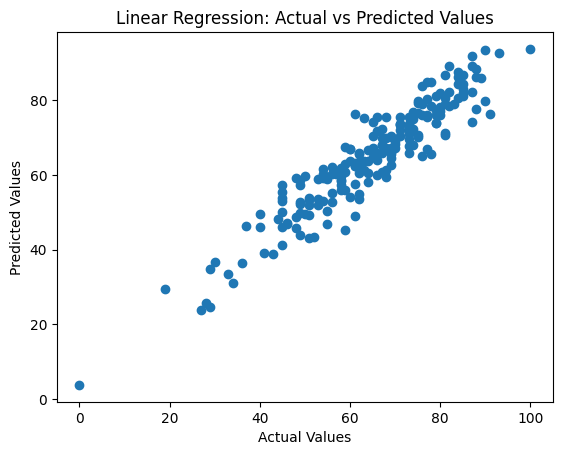

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted Values")
plt.show()

<Axes: xlabel='math_score'>

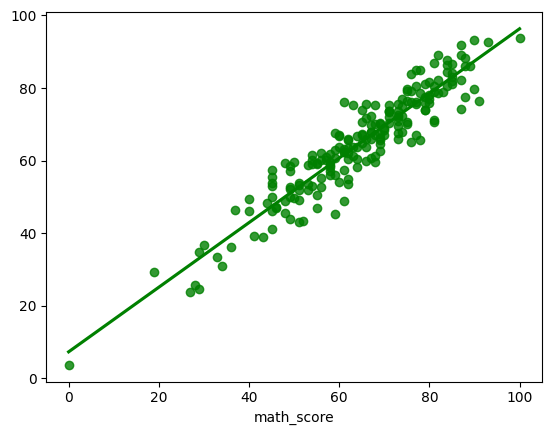

In [87]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='g')

In [89]:
pred_df= pd.DataFrame({'Actual values': y_test, 'Predicted values': y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual values,Predicted values,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
